# Rheological data DFS / Complex viscosity - Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-02

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import math
import re

## Import Data

In [22]:
database = 'Rheological Properties Data Libraries of scl-PHAs_V03'

## Create DataFrames for data points and properties

In [23]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Physchem_properties')

# Complex viscosity properties DataFrame
df_visco = pd.read_excel(f'{database}.xlsx', sheet_name='Complex_viscosity')

# Angular frequency DataFrame
df_angfreq = pd.read_excel(f'{database}.xlsx', sheet_name='Ang_freq_converted(rad.s-1)')

# Experimental details DataFrame
df_exp = pd.read_excel(f'{database}.xlsx', sheet_name='Rheological_experimental_detail')

## Drop duplicates and remove multiple study+instance case (keep first)

In [24]:
print("Physicochemical Properties, rows before:", df_physicochem.shape[0])
df_physicochem = df_physicochem.drop_duplicates(subset=['Study_id', 'Instance'])
print("Physicochemical Properties, rows after:", df_physicochem.shape[0])

Physicochemical Properties, rows before: 336
Physicochemical Properties, rows after: 336


## Keep DFS data

In [25]:
exp_dict_dfs = (
    df_exp[df_exp['Test type'] == 'DFS']
    .groupby('Study_id')['Instance']
    .apply(list)
    .to_dict()
)

In [26]:
# Flatten exp_dict_dfs into a DataFrame of valid (Study_id, Instance) pairs
exp_pairs = [(sid, inst) for sid, instances in exp_dict_dfs.items() for inst in instances]
df_exp_pairs = pd.DataFrame(exp_pairs, columns=['Study_id', 'Instance'])

# Filter df_visco
df_visco_filtered = df_visco.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_angfreq
df_angfreq_filtered = df_angfreq.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_exp
df_exp_filtered = df_exp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# FIlter df_physicochem
df_physic_filtered = df_physicochem.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Check all dfs have the same rows
df_visco_filtered.shape, df_angfreq_filtered.shape, df_exp_filtered.shape, df_physic_filtered.shape

((209, 45), (209, 45), (209, 22), (209, 22))

## Merge properties

In [27]:
df_merged_prop = pd.merge(df_physic_filtered, df_exp_filtered,  on=['Study_id', 'Instance'], how='left')
df_merged_prop.tail()

,Study_id,Instance,Monomer_A,Monomer_B,HB_ratio (mol%),HV_ratio (mol%),Mw_PHBV,Mn_PHBV,Density,Density_units,...,Texp,Texp_units,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz),Unnamed: 18,Unnamed: 19,Unnamed: 20_y,Row No._y
204,55,3c,3HB,3HV,100.0,0.0,500000.0,NaN,NaN,NaN,...,200.0,celsius,Pa*s,NaN,15.0,NaN,NaN,NaN,NaN,324
205,56,1b,3HB,3HV,100.0,0.0,293500.0,NaN,1.25,g/cm3,...,175.0,celsius,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,326
206,58,1,3HB,3HV,100.0,0.0,472000.0,192000.0,NaN,g/cm3,...,180.0,celsius,NaN,dyne/cm^2,15.0,NaN,NaN,NaN,NaN,329
207,58,2,3HB,3HV,100.0,0.0,472000.0,192000.0,NaN,g/cm3,...,180.0,celsius,NaN,dyne/cm^2,15.0,NaN,NaN,NaN,NaN,330
208,58,3,3HB,3HV,100.0,0.0,472000.0,192000.0,NaN,g/cm3,...,180.0,celsius,NaN,dyne/cm^2,15.0,NaN,NaN,NaN,NaN,331


## Melt frequency values

In [28]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_angfreq_filtered.columns if c not in id_cols]

df_angfreq_filtered[value_cols] = df_angfreq_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
f_long = (
    df_angfreq_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="f_value")
    .dropna(subset=["f_value"])
)
f_long.head()

,Study_id,Instance,level_2,f_value
0,1,1,Unnamed: 2,1.000000
1,1,1,Unnamed: 3,1.265630
2,1,1,Unnamed: 4,1.579777
3,1,1,Unnamed: 5,1.999414
4,1,1,Unnamed: 6,2.495695


## Melt visco modulus values

In [29]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_visco_filtered.columns if c not in id_cols]

df_visco_filtered[value_cols] = df_visco_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
v_long = (
    df_visco_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="v_value")
    .dropna(subset=["v_value"])
)
v_long.head()

,Study_id,Instance,level_2,v_value
0,1,1,Unnamed: 2,1334.615380
1,1,1,Unnamed: 3,1300.050175
2,1,1,Unnamed: 4,1249.873606
3,1,1,Unnamed: 5,1217.503127
4,1,1,Unnamed: 6,1170.512534


## Merge f and v values

In [30]:
fv_df = (
    f_long.merge(
        v_long,
        on=["Study_id", "Instance", "level_2"],
        how="inner"
    )
)
fv_df.head()

,Study_id,Instance,level_2,f_value,v_value
0,1,1,Unnamed: 2,1.000000,1334.615380
1,1,1,Unnamed: 3,1.265630,1300.050175
2,1,1,Unnamed: 4,1.579777,1249.873606
3,1,1,Unnamed: 5,1.999414,1217.503127
4,1,1,Unnamed: 6,2.495695,1170.512534


In [31]:
# check size
f_long.shape, v_long.shape, fv_df.shape

((3894, 4), (3119, 4), (3119, 5))

## Merge properties with f,v values

In [32]:
df_merged_fnl = df_merged_prop.merge(
    fv_df[['Study_id', 'Instance', 'f_value', 'v_value']],
    on=['Study_id', 'Instance'],
    how='left'
)
df_merged_fnl = df_merged_fnl.dropna(subset=['f_value', 'v_value'])
df_merged_fnl.tail()

,Study_id,Instance,Monomer_A,Monomer_B,HB_ratio (mol%),HV_ratio (mol%),Mw_PHBV,Mn_PHBV,Density,Density_units,...,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz),Unnamed: 18,Unnamed: 19,Unnamed: 20_y,Row No._y,f_value,v_value
3162,56,1b,3HB,3HV,100.0,0.0,293500.0,NaN,1.25,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,326,16.065,7.338
3163,56,1b,3HB,3HV,100.0,0.0,293500.0,NaN,1.25,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,326,25.729,6.404
3164,56,1b,3HB,3HV,100.0,0.0,293500.0,NaN,1.25,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,326,40.828,5.452
3165,56,1b,3HB,3HV,100.0,0.0,293500.0,NaN,1.25,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,326,65.390,4.758
3166,56,1b,3HB,3HV,100.0,0.0,293500.0,NaN,1.25,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,326,100.000,4.309


In [33]:
df_merged_fnl.shape

(3119, 44)

## Rename columns

In [34]:
df_merged_fnl = df_merged_fnl.rename(columns={
    'f_value': 'ang_frequency',
    'v_value': 'complex_viscosity'
})

df_merged_fnl.columns

Index(['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'HB_ratio (mol%)',
       'HV_ratio (mol%)', 'Mw_PHBV', 'Mn_PHBV', 'Density', 'Density_units',
       'PDI', 'Additive_1', 'Additive1_type', 'Additive1_name',
       'Additive1_percentage (wt%)', 'Additive_2', 'Additive2_type',
       'Additive2_name', 'Additive2_percentage (wt%)',
       'final_formulation_PHA_percentage (wt%)', 'Unnamed: 20_x', 'Row No._x',
       'Test type', 'constant parameters', 'geometry', 'plate diameter',
       'gap size', 'morphology', 'diameter', 'thickness', 'size units',
       'Angular_frequency_units', 'Texp', 'Texp_units', 'Viscosity_units',
       'Modulus_units', 'Strain_fixed(%)', 'Frequency_experimental_fixed (Hz)',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20_y', 'Row No._y',
       'ang_frequency', 'complex_viscosity'],
      dtype='object')

## Drop duplicates

In [35]:
df_merged_fnl = df_merged_fnl.drop_duplicates()

## Replace N/A values with nan

In [36]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

## Fill in Mw, given PDI = Mw / Mn

In [37]:
mask_Mw = (
    df_merged_fnl['Mw_PHBV'].isna() &
    df_merged_fnl['Mn_PHBV'].notna() &
    df_merged_fnl['PDI'].notna()
)

df_merged_fnl.loc[mask_Mw, 'Mw_PHBV'] = (
    df_merged_fnl.loc[mask_Mw, 'PDI'] * df_merged_fnl.loc[mask_Mw, 'Mn_PHBV']
)

## Fix typos, excl. special characters

In [38]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val


In [39]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,monomer_a,monomer_b,hb_ratio_mol,hv_ratio_mol,mw_phbv,mn_phbv,density,density_units,...,viscosity_units,modulus_units,strain_fixed,frequency_experimental_fixed_hz,unnamed_18,unnamed_19,unnamed_20_y,row_no_y,ang_frequency,complex_viscosity
0,1,1,3HB,3HV,97.0,3.0,NaN,NaN,1.24,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,1,1.000000,1334.615380
1,1,1,3HB,3HV,97.0,3.0,NaN,NaN,1.24,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,1,1.265630,1300.050175
2,1,1,3HB,3HV,97.0,3.0,NaN,NaN,1.24,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,1,1.579777,1249.873606
3,1,1,3HB,3HV,97.0,3.0,NaN,NaN,1.24,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,1,1.999414,1217.503127
4,1,1,3HB,3HV,97.0,3.0,NaN,NaN,1.24,g/cm3,...,Pa*s,NaN,1.0,NaN,NaN,NaN,NaN,1,2.495695,1170.512534


In [40]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [41]:
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'density', 'density_units', 'pdi',
       'additive_1', 'additive1_type', 'additive1_name',
       'additive1_percentage_wt', 'additive_2', 'additive2_type',
       'additive2_name', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'unnamed_20_x', 'row_no_x',
       'test_type', 'constant_parameters', 'geometry', 'plate_diameter',
       'gap_size', 'morphology', 'diameter', 'thickness', 'size_units',
       'angular_frequency_units', 'texp', 'texp_units', 'viscosity_units',
       'modulus_units', 'strain_fixed', 'frequency_experimental_fixed_hz',
       'unnamed_18', 'unnamed_19', 'unnamed_20_y', 'row_no_y', 'ang_frequency',
       'complex_viscosity'],
      dtype='object')

In [42]:
df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'no_additive'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'

## Drop features with more than 50% missing values

In [43]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.50]
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'additive_1', 'additive1_type',
       'additive1_name', 'additive1_percentage_wt', 'additive_2',
       'additive2_type', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'row_no_x', 'test_type',
       'constant_parameters', 'geometry', 'plate_diameter', 'size_units',
       'angular_frequency_units', 'texp', 'texp_units', 'viscosity_units',
       'modulus_units', 'strain_fixed', 'row_no_y', 'ang_frequency',
       'complex_viscosity'],
      dtype='object')

## Feature engineering

In [44]:
df_clean['additive1_type'].value_counts()

additive1_type
no_additive                               1281
reinforcment_and_stiffening_modifiers     1229
plasticizers_and_flexibility_enhancers     260
nucleating_agent                           255
crosslinking_agent                          94
Name: count, dtype: int64

In [ ]:
additive1_mapping = {
    # already clean
    "plasticizer": "plasticizer_modifier",
    "impact_modifier": "plasticizer_modifier",
    # structural
    "filler": "reinforcement",
    "reinforcement": "reinforcement",
    # chemistry / network
    "crosslinking_agent": "crosslinker_polymer_modifier",
    "blend_polymer": "crosslinker_polymer_modifier",
    # crystallization
    "nucleating_agent": "nucleating_agent",
    # stabilization
    "antioxidant": "stabilizer",
    # none
    "not_applicable": "not_applicable"
}

In [ ]:
df_clean['additive1_type'] = (
    df_clean['additive1_type']
    .map(additive1_mapping)
    .fillna('other')
)

df_clean['additive1_type'].value_counts()

In [45]:
df_clean['additive2_type'].value_counts()

additive2_type
no_additive                              2901
reinforcment_and_stiffening_modifiers     154
crosslinking_agent                         64
Name: count, dtype: int64

In [ ]:
df_clean['additive2_type'] = (
    df_clean['additive2_type']
    .map(additive1_mapping)
    .fillna('other')
)

df_clean['additive2_type'].value_counts()

## Feature selection

In [46]:
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'additive_1', 'additive1_type',
       'additive1_name', 'additive1_percentage_wt', 'additive_2',
       'additive2_type', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'row_no_x', 'test_type',
       'constant_parameters', 'geometry', 'plate_diameter', 'size_units',
       'angular_frequency_units', 'texp', 'texp_units', 'viscosity_units',
       'modulus_units', 'strain_fixed', 'row_no_y', 'ang_frequency',
       'complex_viscosity'],
      dtype='object')

In [49]:
# Select Features and Target
features = [
            'ang_frequency',
            'study_id',
            'instance',
            'mw_phbv',
            'additive1_type',
            'additive1_percentage_wt',
            'additive2_type',
            'additive2_percentage_wt',
            'hb_ratio_mol',
            'texp',
            'strain_fixed'
           ]
target = 'complex_viscosity'
measure_unit = 'Pa_s'

In [50]:
# Create cleaned DataFrame
df_new = df_clean[features + [target]]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3119 entries, 0 to 3166
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ang_frequency            3119 non-null   float64
 1   study_id                 3119 non-null   int64  
 2   instance                 3119 non-null   object 
 3   mw_phbv                  1806 non-null   float64
 4   additive1_type           3119 non-null   object 
 5   additive1_percentage_wt  3119 non-null   float64
 6   additive2_type           3119 non-null   object 
 7   additive2_percentage_wt  3119 non-null   float64
 8   hb_ratio_mol             3119 non-null   float64
 9   texp                     2964 non-null   float64
 10  strain_fixed             1966 non-null   float64
 11  complex_viscosity        3119 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 316.8+ KB


## Drop rows with nan value

In [51]:
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.head()

,ang_frequency,study_id,instance,mw_phbv,additive1_type,additive1_percentage_wt,additive2_type,additive2_percentage_wt,hb_ratio_mol,texp,strain_fixed,complex_viscosity
324,0.102983,6,1,117869.0,no_additive,0.0,no_additive,0.0,100.0,175.0,1.0,762.852328
325,0.129014,6,1,117869.0,no_additive,0.0,no_additive,0.0,100.0,175.0,1.0,600.169346
326,0.166447,6,1,117869.0,no_additive,0.0,no_additive,0.0,100.0,175.0,1.0,560.417779
327,0.218991,6,1,117869.0,no_additive,0.0,no_additive,0.0,100.0,175.0,1.0,497.082612
328,0.279775,6,1,117869.0,no_additive,0.0,no_additive,0.0,100.0,175.0,1.0,426.053646


In [52]:
df_final['ang_frequency'].describe()

count    1034.000000
mean       37.824274
std        86.414775
min         0.063894
25%         1.321864
50%         6.527000
75%        31.880000
max       623.074464
Name: ang_frequency, dtype: float64

In [53]:
df_final['complex_viscosity'].describe()

count      1034.000000
mean       5502.061092
std       29010.439876
min           1.285556
25%          12.011976
50%          69.715000
75%         641.194916
max      562700.784735
Name: complex_viscosity, dtype: float64

In [54]:
df_final['mw_phbv'].describe()

count    1.034000e+03
mean     5.838914e+05
std      5.346151e+05
min      1.020000e+05
25%      3.500000e+05
50%      4.500000e+05
75%      6.860000e+05
max      2.800000e+06
Name: mw_phbv, dtype: float64

In [55]:
df_final = df_final.copy()
df_final['log_complex_viscosity'] = np.log10(df_final['complex_viscosity'])
df_final['log_ang_frequency'] = np.log10(df_final['ang_frequency'])
df_final['log_mw'] = np.log10(df_final['mw_phbv'])

In [56]:
df_final.columns

Index(['ang_frequency', 'study_id', 'instance', 'mw_phbv', 'additive1_type',
       'additive1_percentage_wt', 'additive2_type', 'additive2_percentage_wt',
       'hb_ratio_mol', 'texp', 'strain_fixed', 'complex_viscosity',
       'log_complex_viscosity', 'log_ang_frequency', 'log_mw'],
      dtype='object')

## Plot feature distribution

In [59]:
# Numerical columns
numerical_cols_lst = [
    'log_complex_viscosity',
    'log_ang_frequency',
    'log_mw',
    'texp',
    'additive1_percentage_wt',
    'additive2_percentage_wt',
    'hb_ratio_mol',
    'strain_fixed'
]
# Categorical columns
categorical_cols_lst = [
    'additive1_type',
    'additive2_type',
]

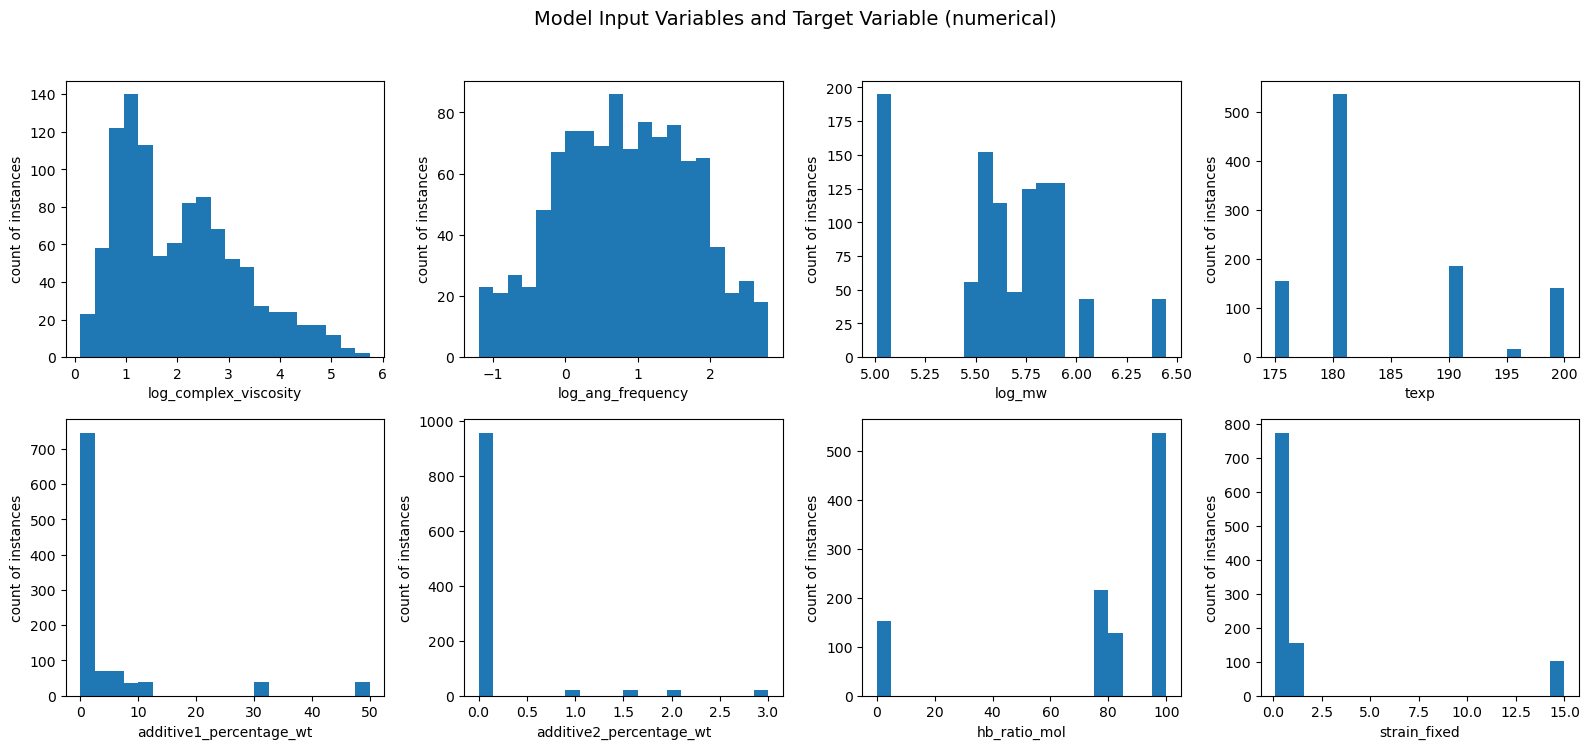

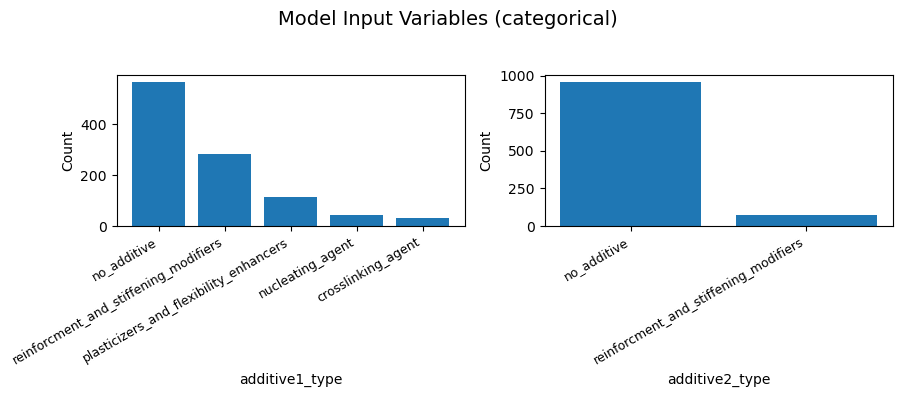

In [60]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("Count")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Remove features with only one value

In [61]:
constant_cols = df_final.columns[df_final.nunique(dropna=True) <= 1]
print("Removed columns:", list(constant_cols))
df_final = df_final.drop(columns=constant_cols)

Removed columns: []


In [62]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1034 entries, 324 to 3166
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ang_frequency            1034 non-null   float64
 1   study_id                 1034 non-null   int64  
 2   instance                 1034 non-null   object 
 3   mw_phbv                  1034 non-null   float64
 4   additive1_type           1034 non-null   object 
 5   additive1_percentage_wt  1034 non-null   float64
 6   additive2_type           1034 non-null   object 
 7   additive2_percentage_wt  1034 non-null   float64
 8   hb_ratio_mol             1034 non-null   float64
 9   texp                     1034 non-null   float64
 10  strain_fixed             1034 non-null   float64
 11  complex_viscosity        1034 non-null   float64
 12  log_complex_viscosity    1034 non-null   float64
 13  log_ang_frequency        1034 non-null   float64
 14  log_mw                   10

## Save

In [63]:
df_final.to_csv('rheological_DFS_data_viscosity_LM.csv', index=False)

## Profiling

In [64]:
import sweetviz as sv

exclude_cols = ['study_id', 'instance']
df_subset = df_final.drop(columns=exclude_cols)

report = sv.analyze(df_subset)
report.show_html("dataset_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## OLD

In [ ]:
# Ensure Study_id is integer
df_time['Study_id'] = df_time['Study_id'].astype(int)

# Extract the columns after 'Sample_name' for time and weight
time_cols = df_time.columns[df_time.columns.get_loc('Sample_name') + 1:]
weight_cols = df_weight.columns[df_weight.columns.get_loc('Sample_name') + 1:]

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subfigure 1: Study_id=19, Instance='1b'
mask1 = (df_time['Study_id'] == 19) & (df_time['Instance'] == '1b')
axes[0].plot(df_time.loc[mask1, time_cols].values.flatten(),
             df_weight.loc[mask1, weight_cols].values.flatten(),
             marker='o', linestyle='-')
axes[0].set_title('study_id: 19, instance: 1b')
axes[0].set_xlabel('Degradation time (days)')
axes[0].set_ylabel('Weight Loss (%)')
axes[0].set_ylim(0, 10)  # y-axis limit for first subplot

# Subfigure 2: Study_id=21, Instance=5
mask2 = (df_time['Study_id'] == 21) & (df_time['Instance'] == 5)
axes[1].plot(df_time.loc[mask2, time_cols].values.flatten(),
             df_weight.loc[mask2, weight_cols].values.flatten(),
             marker='o', linestyle='-')
axes[1].set_title('study_id: 21, instance: 5')
axes[1].set_xlabel('Degradation time (days)')
axes[1].set_ylim(0, 105)  # y-axis limit for second subplot

plt.tight_layout()

plt.savefig(
    "two_examples.tiff",
    format="tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
def _grid_dims(n, max_cols):
    cols = min(max_cols, max(1, n))
    rows = int(math.ceil(n / cols))
    return rows, cols
    
def plot_numerical_distributions(
    df: pd.DataFrame,
    numerical_cols,
    title="Model Input Variables and Target Variable (numerical)",
    bins=20,
    max_cols_per_row=4,
    save_path=None,          # e.g. "numerical_features.tiff"
    dpi=600
):
    # ---- filter columns ----
    numerical_cols = [c for c in numerical_cols if c != "study_id"]

    # force Weight_mass_loss_% first
    if "weight_loss" in numerical_cols:
        numerical_cols = (
            ["weight_loss"]
            + [c for c in numerical_cols if c != "weight_loss"]
        )

    if len(numerical_cols) == 0:
        return

    n = len(numerical_cols)
    rows, cols = _grid_dims(n, max_cols_per_row)

    fig, axes = plt.subplots(rows, cols, figsize=(4.0 * cols, 3.8 * rows))
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontsize=14, y=0.98)

    for i, col in enumerate(numerical_cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        x = df[col].dropna().values
        ax.hist(x, bins=bins)
        ax.set_ylabel("Count")
        ax.set_xlabel(str(col))
        ax.grid(False)

    # hide empty axes
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, format="tiff", dpi=dpi, bbox_inches="tight")

    plt.show()

In [ ]:
def plot_categorical_distributions(
    df: pd.DataFrame,
    categorical_cols,
    title="Model Input Variables (categorical)",
    max_cols_per_row=4,
    top_k_categories=20,
    save_path=None,          # e.g. "categorical_features.tiff"
    dpi=600
):
    # ---- filter columns ----
    categorical_cols = [c for c in categorical_cols if c != "instance"]

    if len(categorical_cols) == 0:
        return

    n = len(categorical_cols)
    rows, cols = _grid_dims(n, max_cols_per_row)

    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.0 * rows))
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontsize=14, y=0.98)

    for i, col in enumerate(categorical_cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]

        vc = (
            df[col]
            .astype(str)
            .replace("nan", np.nan)
            .value_counts(dropna=False)
            .head(top_k_categories)
        )

        ax.bar(range(len(vc)), vc.values)
        ax.set_xticks(range(len(vc)))
        ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Count")
        ax.set_xlabel(str(col))
        ax.grid(False)

    # hide empty axes
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, format="tiff", dpi=dpi, bbox_inches="tight")

    plt.show()

In [ ]:
plot_numerical_distributions(
    df_final,
    numerical_cols_lst,
    save_path="numerical_features.tiff"
)

plot_categorical_distributions(
    df_final,
    categorical_cols_lst,
    save_path="categorical_features.tiff"
)